# 1. Importing the data and modules

the data was downloaded yousing the following *Google Earth Engine* script: https://code.earthengine.google.com/04afb4de7a1d95d988d2972e3ed87ffd.

Band positions: 
1. Blue
2. Green 
3. Red 
4. NIR 
5. SWIR1
6. SWIR2
7. TIR1


In [51]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cmcrameri.cm as cmc

In [107]:
year_list = np.arange(1985, 2025, 3) # array with al the year we have data from
LST = xr.Dataset()

LST_array = []
Red_array = []
NIR_array = []
for year in year_list:
        filepath = f"../data/raw/LandsatComposite_Zurich_{year}.tif"
        with xr.open_dataset(filepath, engine = "rasterio") as src:
            src_t = src.expand_dims(time=[year])# add time as a coordinate
            LST_array.append(src_t.sel(band = 7).band_data)
            Red_array.append(src_t.sel(band = 3).band_data)
            NIR_array.append(src_t.sel(band = 4).band_data)


LST = xr.concat(LST_array, dim="time")# turn into xr data array
Red = xr.concat(Red_array, dim = "time")
NIR = xr.concat(NIR_array, dim = "time")


# 2. Analyse Trends in NDVI and LST
## 2.1 calculate NDVI

In [108]:
# extract year values from data Cube
NIR_2024 = NIR.sel(time = 2024)
Red_2024 = Red.sel(time = 2024)
NIR_1985 = NIR.sel(time = 1985)
Red_1985 = Red.sel(time = 1985)

# calculate NDVO for each year

NDVI_2024 = (NIR_2024 - Red_2024)/(NIR_2024 + Red_2024)
NDVI_1985 = (NIR_1985 - Red_1985)/(NIR_1985 + Red_1985)

## 2.2 Map of the differences in NDVI and LST

<xarray.DataArray 'band_data' (y: 252, x: 297)> Size: 599kB
array([[297.02761016, 297.37112117, 297.67361594, ..., 297.58474742,
        297.56082128, 297.3249779 ],
       [296.06714654, 296.39014943, 296.5217432 , ..., 297.64285376,
        297.53689514, 297.27028958],
       [295.44335789, 295.77832385, 295.42114076, ..., 298.4700146 ,
        297.77273852, 297.44973563],
       ...,
       [301.41805685, 301.8025841 , 300.66951047, ..., 303.02965328,
        302.45542592, 302.40757364],
       [301.15999634, 301.31722526, 301.16341436, ..., 303.23131646,
        302.5545485 , 302.47935206],
       [300.90706286, 301.0335296 , 301.00618544, ..., 303.35436518,
        302.68101524, 302.53062236]], shape=(252, 297))
Coordinates:
  * y            (y) float64 2kB 5.253e+06 5.253e+06 ... 5.245e+06 5.245e+06
  * x            (x) float64 2kB 4.6e+05 4.6e+05 4.6e+05 ... 4.688e+05 4.689e+05
    time         int64 8B 1985
    band         int64 8B 7
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    long_name:      ('Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'TIR1')

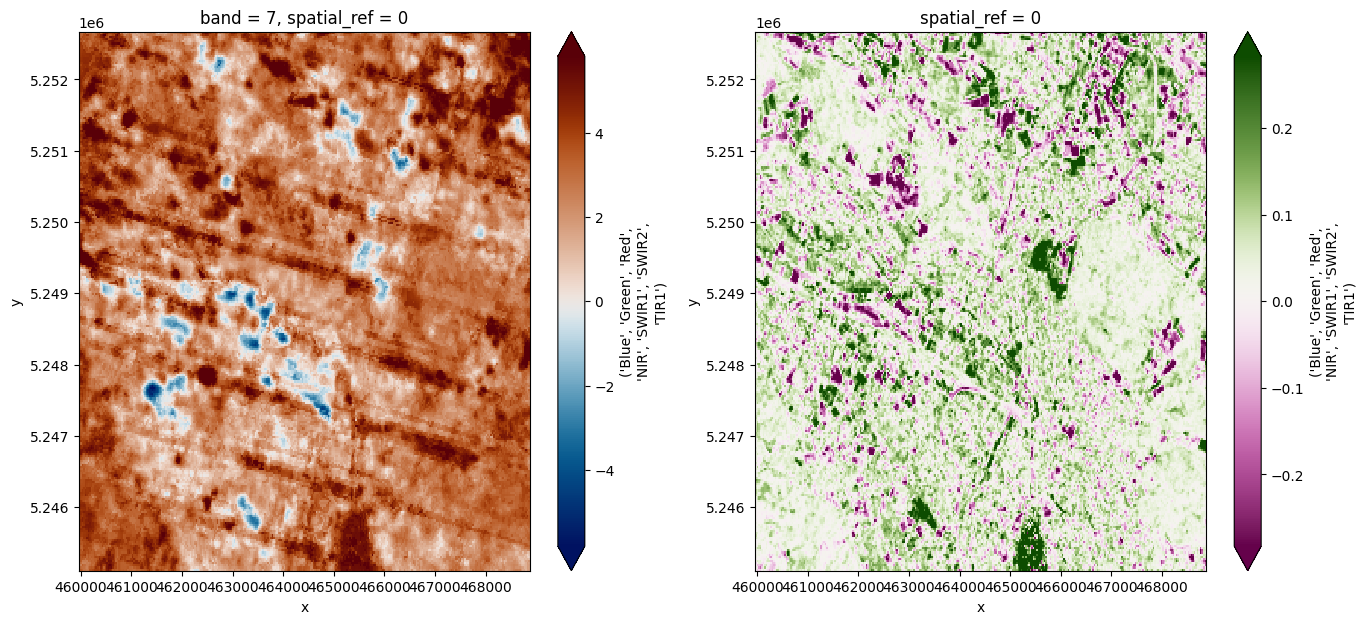

In [109]:
# extract year values from data Cube
LST_2024 = LST.sel(time = 2024)
LST_1985 = LST.sel(time = 1985)

dif_NDVI = NDVI_2024 - NDVI_1985 
dif_LST = LST_2024 - LST_1985 

fig , ax = plt.subplots(1,2, figsize = (16,7))

#determine vmin/max LST
LST_min = np.percentile(dif_LST, 2)# percentile to crop outliers
LST_max = np.percentile(dif_LST.values, 98)
LST_bound = max(abs(LST_min), abs(LST_max))# center around 0
#plot LST
dif_LST.plot(ax=ax[0],
            vmin = - LST_bound, 
            vmax = LST_bound,
            cmap = cmc.vik)


#determine vmin/max NDVI
NDVI_min = np.percentile(dif_NDVI, 2)# percentile to crop outliers
NDVI_max = np.percentile(dif_NDVI, 98)
NDVI_bound = max(abs(NDVI_min), abs(NDVI_max))# center around 0
#plot NDVI
dif_NDVI.plot(ax=ax[1], 
              vmin = -NDVI_bound, 
              vmax = NDVI_bound,
              cmap = cmc.bam)


## note: for reference: add lables, context etc. lake etc.
LST_2024
LST_1985

##  2.2 Change in Time